In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Mostramos el contenido de tu Google Drive
os.listdir("/content/drive/MyDrive")


['Documento sin título (2).gdoc',
 'diagrama flujos parcial.png',
 'Copia de Presentacion Software.gslides',
 'pacmanComplejo.txt',
 'pacmanSimple.txt',
 'Classroom',
 'Información árticulos.gdoc',
 'Documento sin título (1).gdoc',
 'Práctica 0.gsheet',
 'casos de uso.gdoc',
 'ProyectoFinal.pdf',
 '2 cuatri 3.pdf',
 'Documento sin título.gdoc',
 'Capítulo 3 - Guía definitiva de las Competencias Laborales.pdf',
 'DescripciónPuestoTrabajo (1).pdf',
 'DescripciónPuestoTrabajo.pdf',
 'DescripciónPuestoTrabajo (1).gdoc',
 'DescripciónPuestoTrabajo.gdoc',
 'Ego surfing Daniel.gsheet',
 'EgosurgingLydia.gsheet',
 'EgosurfingDaniel.gsheet',
 'Resumen Ejecutivo.gdoc',
 'Copia de Relación mucho a muchos.gslides',
 'Relación mucho a muchos.gslides',
 'pcap 221 mb',
 'data test.gsheet',
 'Ev Continua dsi.gsheet',
 'Vision directiva Dsi.gdoc',
 'Copia de resumen extendido recursos.gdoc',
 'paso8.1.png',
 'Memoria Cripto.gdoc',
 'Colab Notebooks',
 'Test_autocorregible.gsheet',
 '[2526

In [ ]:
import os

os.listdir("/content/drive/MyDrive/[2526] Datasets OCR")


['numeros', 'minusculas', 'mayusculas', 'Datasets OCR otros años']

In [ ]:
import os

ruta_base = "/content/drive/MyDrive/[2526] Datasets OCR/"

os.listdir(os.path.join(ruta_base, "mayusculas"))


['Ñ',
 'H',
 'F',
 'J',
 'E',
 'G',
 'B',
 'C',
 'A',
 'D',
 'I',
 'S',
 'Q',
 'O',
 'N',
 'P',
 'L',
 'M',
 'T',
 'K',
 'R',
 'V',
 'U',
 'Z',
 'X',
 'W',
 'Y']

In [ ]:
import cv2

ruta_A = os.path.join(ruta_base, "mayusculas", "A")

imagenes_A = []

for archivo in os.listdir(ruta_A):
    if archivo.lower().endswith((".png", ".jpg", ".jpeg")):
        ruta_img = os.path.join(ruta_A, archivo)
        img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            imagenes_A.append(img)

print("Número de imágenes de la letra A:", len(imagenes_A))


Número de imágenes de la letra A: 38


In [ ]:
import cv2
import os

imagenes = []
etiquetas = []

ruta_mayusculas = os.path.join(ruta_base, "mayusculas")

for letra in os.listdir(ruta_mayusculas):
    ruta_letra = os.path.join(ruta_mayusculas, letra)

    if os.path.isdir(ruta_letra):
        for archivo in os.listdir(ruta_letra):
            if archivo.lower().endswith((".png", ".jpg", ".jpeg")):
                ruta_img = os.path.join(ruta_letra, archivo)
                img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

                if img is not None:
                    imagenes.append(img)
                    etiquetas.append(letra)

print("Total de imágenes cargadas:", len(imagenes))
print("Ejemplo de etiquetas:", etiquetas[:10])


Total de imágenes cargadas: 1019
Ejemplo de etiquetas: ['Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ']


In [ ]:
# Comprobamos el tamaño de la primera imagen
imagenes[0].shape


(64, 64)

In [ ]:
import cv2
import numpy as np

imagenes_limpias = []
etiquetas_limpias = []

for img, etiqueta in zip(imagenes, etiquetas):
    if img is not None:
        # Forzamos tamaño 64x64
        img_resized = cv2.resize(img, (64, 64))
        imagenes_limpias.append(img_resized)
        etiquetas_limpias.append(etiqueta)

print("Imágenes originales:", len(imagenes))
print("Imágenes limpias:", len(imagenes_limpias))


Imágenes originales: 1019
Imágenes limpias: 1019


In [ ]:
X = np.array([img.flatten() for img in imagenes_limpias])
y = np.array(etiquetas_limpias)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (1019, 4096)
Forma de y: (1019,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba
    random_state=42,
    stratify=y          # mantiene proporción de letras
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (815, 4096)
Prueba: (204, 4096)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")


Modelo entrenado correctamente


In [ ]:
from sklearn.metrics import accuracy_score

# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Precisión
precision = accuracy_score(y_test, y_pred)

print("Precisión del OCR:", precision)


Precisión del OCR: 0.12254901960784313


In [ ]:
from skimage.feature import hog
import numpy as np

def extraer_hog(imagen):
    features = hog(
        imagen,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    return features


In [ ]:
# Extraemos HOG para train y test
X_train_hog = np.array([extraer_hog(img.reshape(64, 64)) for img in X_train])
X_test_hog  = np.array([extraer_hog(img.reshape(64, 64)) for img in X_test])

print("Train HOG:", X_train_hog.shape)
print("Test HOG:", X_test_hog.shape)


Train HOG: (815, 1764)
Test HOG: (204, 1764)


In [ ]:
from sklearn.svm import SVC

# Creamos el modelo SVM
svm = SVC(kernel='rbf', C=10, gamma='scale')

# Entrenamos con HOG
svm.fit(X_train_hog, y_train)

print("SVM entrenado correctamente")


SVM entrenado correctamente


In [ ]:
from sklearn.metrics import accuracy_score

# Predicciones del SVM
y_pred_svm = svm.predict(X_test_hog)

# Precisión
precision_svm = accuracy_score(y_test, y_pred_svm)

print("Precisión OCR con HOG + SVM:", precision_svm)


Precisión OCR con HOG + SVM: 0.696078431372549


In [ ]:
import numpy as np

# Convertimos la lista de imágenes a array
X_cnn = np.array(imagenes_limpias)

# Normalizamos píxeles
X_cnn = X_cnn / 255.0

# Añadimos canal (escala de grises)
X_cnn = X_cnn.reshape(-1, 64, 64, 1)

y_cnn = np.array(etiquetas_limpias)

print("Forma X:", X_cnn.shape)
print("Forma y:", y_cnn.shape)


Forma X: (1019, 64, 64, 1)
Forma y: (1019,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Codificamos letras a números
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_cnn)

# Convertimos a one-hot
y_onehot = to_categorical(y_encoded)

print("Ejemplo etiquetas originales:", y_cnn[:5])
print("Ejemplo etiquetas codificadas:", y_encoded[:5])
print("Forma y_onehot:", y_onehot.shape)


Ejemplo etiquetas originales: ['Ñ' 'Ñ' 'Ñ' 'Ñ' 'Ñ']
Ejemplo etiquetas codificadas: [14 14 14 14 14]
Forma y_onehot: (1019, 27)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train X:", X_train_cnn.shape)
print("Test X:", X_test_cnn.shape)
print("Train y:", y_train_cnn.shape)
print("Test y:", y_test_cnn.shape)


Train X: (815, 64, 64, 1)
Test X: (204, 64, 64, 1)
Train y: (815, 27)
Test y: (204, 27)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
model = Sequential()

# Capa convolucional 1
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(64, 64, 1)
))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Capa convolucional 2
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanado
model.add(Flatten())

# Capa densa
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Capa de salida (27 clases)
model.add(Dense(27, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,059 (6.21 MB)

 Trainable params: 1,628,059 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn)
)


Epoch 1/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.0556 - loss: 3.3951 - val_accuracy: 0.0490 - val_loss: 3.2916
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.0605 - loss: 3.2851 - val_accuracy: 0.1520 - val_loss: 3.2267
Epoch 3/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.1189 - loss: 3.1418 - val_accuracy: 0.3235 - val_loss: 2.8470
Epoch 4/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.2512 - loss: 2.7476 - val_accuracy: 0.3922 - val_loss: 2.4098
Epoch 5/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.3431 - loss: 2.3565 - val_accuracy: 0.4510 - val_loss: 2.1595
Epoch 6/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4769 - loss: 2.0218 - val_accuracy: 0.5049 - val_loss: 1.9156
Epoch 7/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.5321 - loss: 1.6897 - val_accuracy: 0.5490 - val_loss: 1.7508
Epoch 8/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5654 - loss: 1.5462 - val_accuracy: 0.5

In [ ]:
import cv2
import os

imagenes_all = []
etiquetas_all = []

ruta_base = "/content/drive/MyDrive/[2526] Datasets OCR/"

# ---------- MAYÚSCULAS ----------
ruta_may = os.path.join(ruta_base, "mayusculas")

for letra in os.listdir(ruta_may):
    ruta_letra = os.path.join(ruta_may, letra)
    if os.path.isdir(ruta_letra):
        for archivo in os.listdir(ruta_letra):
            if archivo.lower().endswith(".png"):
                img = cv2.imread(os.path.join(ruta_letra, archivo), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (64, 64))
                    imagenes_all.append(img)
                    etiquetas_all.append(letra)   # A, B, Ñ...

# ---------- MINÚSCULAS ----------
ruta_min = os.path.join(ruta_base, "minusculas")

for letra in os.listdir(ruta_min):
    ruta_letra = os.path.join(ruta_min, letra)
    if os.path.isdir(ruta_letra):
        for archivo in os.listdir(ruta_letra):
            if archivo.lower().endswith(".png"):
                img = cv2.imread(os.path.join(ruta_letra, archivo), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (64, 64))
                    imagenes_all.append(img)
                    etiquetas_all.append(letra.lower())  # a, b, ñ...

# ---------- NÚMEROS ----------
ruta_num = os.path.join(ruta_base, "numeros")

for num in os.listdir(ruta_num):
    ruta_numero = os.path.join(ruta_num, num)
    if os.path.isdir(ruta_numero):
        for archivo in os.listdir(ruta_numero):
            if archivo.lower().endswith(".png"):
                img = cv2.imread(os.path.join(ruta_numero, archivo), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (64, 64))
                    imagenes_all.append(img)
                    etiquetas_all.append(num)   # '0', '1', ...

print("Total imágenes:", len(imagenes_all))
print("Ejemplo etiquetas:", etiquetas_all[:20])


Total imágenes: 2218
Ejemplo etiquetas: ['Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ', 'Ñ']


In [ ]:
import numpy as np

# Convertimos a array
X_all = np.array(imagenes_all)

# Normalizamos
X_all = X_all / 255.0

# Añadimos canal (grises)
X_all = X_all.reshape(-1, 64, 64, 1)

y_all = np.array(etiquetas_all)

print("Forma X_all:", X_all.shape)
print("Forma y_all:", y_all.shape)


Forma X_all: (2218, 64, 64, 1)
Forma y_all: (2218,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder_all = LabelEncoder()
y_all_encoded = encoder_all.fit_transform(y_all)

y_all_onehot = to_categorical(y_all_encoded)

print("Número de clases:", y_all_onehot.shape[1])


Número de clases: 64


In [ ]:
from sklearn.model_selection import train_test_split

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_all_encoded
)

print("Train X:", X_train_all.shape)
print("Test X:", X_test_all.shape)
print("Train y:", y_train_all.shape)
print("Test y:", y_test_all.shape)


Train X: (1774, 64, 64, 1)
Test X: (444, 64, 64, 1)
Train y: (1774, 64)
Test y: (444, 64)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = y_all_onehot.shape[1]

model_all = Sequential()

model_all.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model_all.add(MaxPooling2D((2, 2)))

model_all.add(Conv2D(64, (3, 3), activation='relu'))
model_all.add(MaxPooling2D((2, 2)))

model_all.add(Flatten())
model_all.add(Dense(128, activation='relu'))
model_all.add(Dropout(0.5))

model_all.add(Dense(num_classes, activation='softmax'))

model_all.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,832 (6.23 MB)

 Trainable params: 1,632,832 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_all.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_all = model_all.fit(
    X_train_all,
    y_train_all,
    epochs=40,
    batch_size=32,
    validation_data=(X_test_all, y_test_all)
)


Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.0145 - loss: 4.1662 - val_accuracy: 0.0248 - val_loss: 4.1552
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.0272 - loss: 4.1355 - val_accuracy: 0.0923 - val_loss: 4.0355
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.0835 - loss: 3.8896 - val_accuracy: 0.1622 - val_loss: 3.5990
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.1753 - loss: 3.3588 - val_accuracy: 0.2635 - val_loss: 3.1752
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.2914 - loss: 2.8892 - val_accuracy: 0.3063 - val_loss: 2.8559
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.3550 - loss: 2.5034 - val_accuracy: 0.3536 - val_loss: 2.7097
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.4383 - loss: 2.1760 - val_accuracy: 0.3311 - val_loss: 2.5946
Epoch 8/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.4973 - loss: 2.0005 - val_accuracy: 0

In [ ]:
import cv2
import numpy as np

def ocr_predecir_imagen(ruta_imagen, modelo, encoder):
    # Cargar imagen
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("No se pudo cargar la imagen")

    # Preprocesado igual que entrenamiento
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = img.reshape(1, 64, 64, 1)

    # Predicción
    pred = modelo.predict(img)
    clase = np.argmax(pred)

    # Convertir número a etiqueta original
    letra = encoder.inverse_transform([clase])[0]

    return letra


In [ ]:
model_all.save("/content/ocr_model_all.h5")


In [ ]:

from tensorflow.keras.models import load_model

model_all = load_model("/content/ocr_model_all.h5")


In [ ]:
import pickle

# Save the encoder_all object to the file first
with open("/content/encoder_all.pkl", "wb") as f:
    pickle.dump(encoder_all, f)

# Now load the encoder_all object from the file
with open("/content/encoder_all.pkl", "rb") as f:
    encoder_all = pickle.load(f)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar_letras(ruta_imagen):
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("No se pudo cargar la imagen")

    # Binarización
    _, thresh = cv2.threshold(img, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Encontrar contornos (letras)
    contornos, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    letras = []

    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)

        # Filtro para evitar ruido
        if w > 10 and h > 10:
            letra = img[y:y+h, x:x+w]
            letras.append((x, letra))

    # Ordenar de izquierda a derecha
    letras = sorted(letras, key=lambda x: x[0])

    return [l[1] for l in letras]


Número de letras detectadas: 5


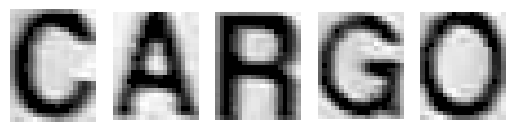

In [ ]:
letras = segmentar_letras("/content/frase_prueba.png")

print("Número de letras detectadas:", len(letras))

for i, l in enumerate(letras):
    plt.subplot(1, len(letras), i+1)
    plt.imshow(l, cmap="gray")
    plt.axis("off")


In [ ]:
def ocr_frase(ruta_imagen, modelo, encoder):
    letras = segmentar_letras(ruta_imagen)
    resultado = ""

    for letra_img in letras:
        letra_img = cv2.resize(letra_img, (64, 64))
        letra_img = letra_img / 255.0
        letra_img = letra_img.reshape(1, 64, 64, 1)

        pred = modelo.predict(letra_img)
        clase = np.argmax(pred)
        caracter = encoder.inverse_transform([clase])[0]

        resultado += caracter

    return resultado


In [ ]:
texto = ocr_frase(
    "/content/frase_prueba.png",
    model_all,
    encoder_all
)

print("Texto reconocido:", texto)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Texto reconocido: ikiii


In [ ]:

resultado = ocr_predecir_imagen(
    "/content/mi_prueba.png",
    model_all,
    encoder_all
)

print("Letra reconocida:", resultado)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Letra reconocida: A
